In [1]:
using Pkg
Pkg.activate("/global/homes/j/jgmorawe/desi-emulators-pipeline")

  Activating project at `~/desi-emulators-pipeline`


In [3]:
using Mapse
using Effort
using PyCall
using Plots
using NPZ
using DelimitedFiles

In [4]:
# Reads in each of the emulator components
emu_path = "/global/homes/j/jgmorawe/desi-emulators-pipeline-Mapse-only/trained_mapse_class_mnuw0wacdm_100000"
Pk_lin_cb_emu = Mapse.load_emulator(emu_path * "/Pk_lin_cb", preprocessing_name="drop_primordial_parameters", postprocessing_name="lcdm_transfer_ratio")
Pk_lin_mm_emu = Mapse.load_emulator(emu_path * "/Pk_lin_mm", preprocessing_name="drop_primordial_parameters", postprocessing_name="lcdm_transfer_ratio")

TransferFunctionEmulator(AbstractCosmologicalEmulators.LuxEmulator{Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_6::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, @NamedTuple{layer_1::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_2::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_3::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_4::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_5::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_6::@NamedTuple{weight::Matrix{Float32}, bias::Vector{F

In [5]:
# Makes a test set of cosmological parameters and redshift
input_params = [2.9, 0.9, 74, 0.021, 0.14, 0.15, -0.8, -1.1]
z = 0.7
effort_cosmo = Effort.w0waCDMCosmology(ln10Aₛ=input_params[1], nₛ=input_params[2], h=input_params[3]/100, ωb=input_params[4], ωc=input_params[5], 
                                       mν=input_params[6], w0=input_params[7], wa=input_params[8], ωk=0)
D = Effort.D_z(z, effort_cosmo)
# Extracts the Pk for each component
result_cb = Mapse.get_Pk(input_params, z, D, Pk_lin_cb_emu)
result_mm = Mapse.get_Pk(input_params, z, D, Pk_lin_mm_emu) 

2000-element Vector{Float64}:
 7799.945538723701
 7831.0112047292605
 7862.190357310898
 7893.483241349824
 7924.890100413016
 7956.411176222481
 7988.046709058959
 8019.79693744992
 8051.662098226675
 8083.642426750046
 8115.738156688183
 8147.949519982515
 8180.27674603318
    ⋮
    0.12064109601313185
    0.11915227478308253
    0.11768163386693592
    0.1162289541558246
    0.11479401910445011
    0.11337661470355226
    0.11197652945361077
    0.11059355434099159
    0.10922748281181845
    0.10787811074734621
    0.10654523643962724
    0.105228660565822

In [6]:
# Calculates exact version for each component
classy = pyimport("classy")
nk = 2000
k_grid = exp.(range(log(1e-3), log(10), length=nk))
cosmo_params = Dict(
    "output" => "mPk",
    "P_k_max_1/Mpc" => 15.0, # physical k max
    "z_pk" => string(z),
    "ln10^{10}A_s" => input_params[1],
    "n_s" => input_params[2],
    "h" => input_params[3]/100,
    "omega_b" => input_params[4],
    "omega_cdm" => input_params[5],
    "m_ncdm" => input_params[6],
    "w0_fld" => input_params[7],
    "wa_fld" => input_params[8],
    "tau_reio" => 0.0568,
    "N_ur" => 2.0308,
    "N_ncdm" => 1,
    "use_ppf" => "yes",
    "fluid_equation_of_state" => "CLP",
    "cs2_fld" => 1,
    "Omega_Lambda" => 0,
    "Omega_scf" => 0)
cosmo = classy.Class()
cosmo.set(cosmo_params)
cosmo.compute()
Pcb_exact = [cosmo.pk_cb(k, z) for k in k_grid]
Pmm_exact = [cosmo.pk(k, z) for k in k_grid]

2000-element Vector{Float64}:
 7803.283731102023
 7834.43132476422
 7865.690435257257
 7897.061301825699
 7928.544162881171
 7960.139255988599
 7991.846817852464
 8023.667084302911
 8055.600290281739
 8087.646669828403
 8119.806456065876
 8152.079881186434
 8184.467176437438
    ⋮
    0.12061711782511593
    0.11912855200504824
    0.11765816902984423
    0.11620574825422027
    0.11477107170371129
    0.11335392404228431
    0.11195409254034586
    0.11057136704314137
    0.10920553993953774
    0.10785640613118884
    0.10652376300207475
    0.10520741038841502

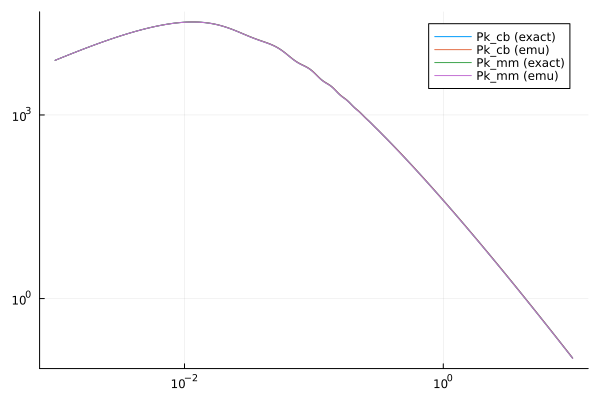

In [7]:
# Overlays the exact and emulator versions to compare
plot(k_grid, Pcb_exact, xscale=:log10, yscale=:log10, label="Pk_cb (exact)")
plot!(k_grid, result_cb, label="Pk_cb (emu)")
plot!(k_grid, Pmm_exact, label="Pk_mm (exact)")
plot!(k_grid, result_mm, label="Pk_mm (emu)")

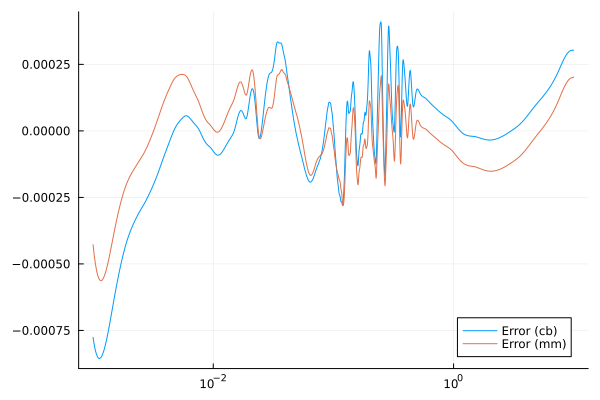

In [8]:
# Plots the percentage error for each to visualize
plot(k_grid, (result_cb .- Pcb_exact) ./ Pcb_exact, xscale=:log10, label="Error (cb)")
plot!(k_grid, (result_mm .- Pmm_exact) ./ Pmm_exact, label="Error (mm)")